# Pipeline V6 — Analyse par Cadence avec Protocole B

**Objectif** : Évaluer la prédiction du Elo sur seulement **N=10 parties** par joueur,
par cadence (bullet / blitz / rapid), avec analyse fine de l'importance des features.

**Étapes :**
1. Chargement & nettoyage (taxonomie basée sur `cp_loss_clean`)
2. Agrégation game-level & player-level
3. Population par cadence — joueurs éligibles (≥ 10 parties)
4. **Protocole B** : train ET test sur N=10 parties — comparaison Ridge / XGBoost / LightGBM / CatBoost
5. Feature importance par permutation — Top / Bottom / Candidats au pruning
6. Comparaison des blocs entre cadences
7. Synthèse finale & recommandations


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Section 0 — Imports & Configuration

In [6]:
# — Google Colab uniquement — décommenter si nécessaire
# from google.colab import drive
# drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost disponible")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost non disponible")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("✓ LightGBM disponible")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠ LightGBM non disponible")

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
    print("✓ CatBoost disponible")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("⚠ CatBoost non disponible — pip install catboost")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Chemins ── adapter selon votre environnement ───────────────────────────────
DATA_DIR     = Path('/content/drive/MyDrive/Data-PMIND-1000x100')   # Colab : Path('/content/drive/MyDrive/Data-PMIND-Final')
MOVES_PATH   = DATA_DIR / 'moves.csv'
GAMES_PATH   = DATA_DIR / 'games.csv'
SUMMARY_PATH = DATA_DIR / 'summary.csv'
PLAYERS_PATH = DATA_DIR / 'players.csv'

RANDOM_STATE     = 42
N_GAMES_PROTO    = 10   # ← nombre de parties par joueur pour le Protocole B
N_REPEATS        = 10   # ← répétitions pour stabiliser l'estimation
CADENCES_KEEP    = ['bullet', 'blitz', 'rapid']
MIN_GAMES_PLAYER = 10   # ← seuil d'éligibilité : joueurs avec >= N parties
EVAL_CAP         = 900
LOSS_CAP         = 600
THRESHOLD_WIN    = 150
THRESHOLD_LOSE   = -150
LOW_CLOCK_RATIO  = 0.20

print("\n✓ Configuration OK")
print(f"  Cadences : {CADENCES_KEEP}")
print(f"  Protocole B : N={N_GAMES_PROTO} parties, {N_REPEATS} répétitions")


✓ XGBoost disponible
✓ LightGBM disponible
⚠ CatBoost non disponible — pip install catboost

✓ Configuration OK
  Cadences : ['bullet', 'blitz', 'rapid']
  Protocole B : N=10 parties, 10 répétitions


---
## Section 1 — Chargement des Données

In [7]:
def load_data(moves_path, games_path, summary_path, players_path):
    moves   = pd.read_csv(moves_path)
    games   = pd.read_csv(games_path)
    summary = pd.read_csv(summary_path)
    players = pd.read_csv(players_path)
    print(f"moves   : {moves.shape[0]:>8,} lignes x {moves.shape[1]} colonnes")
    print(f"games   : {games.shape[0]:>8,} lignes x {games.shape[1]} colonnes")
    print(f"players : {players.shape[0]:>8,} lignes x {players.shape[1]} colonnes")
    return moves, games, summary, players

moves, games, summary, players = load_data(MOVES_PATH, GAMES_PATH, SUMMARY_PATH, PLAYERS_PATH)


moves   : 6,469,097 lignes x 23 colonnes
games   :  100,000 lignes x 23 colonnes
players :    1,000 lignes x 12 colonnes


---
## Section 2 — Nettoyage des Moves

**Correction V6** : taxonomie d'erreurs basée sur `cp_loss_clean`
(annotation moteur directe), pas sur `loss_capped` (reconstruction depuis les évals).


In [8]:
def clean_moves(moves):
    df = moves.copy()

    # 1. Clamp des évals
    df['eval_before_capped'] = df['eval_white_before'].clip(-EVAL_CAP, EVAL_CAP)
    df['eval_after_capped']  = df['eval_white_after'].clip(-EVAL_CAP, EVAL_CAP)

    # 2. Perte reconstruite (diagnostic uniquement)
    df['loss_signed'] = np.where(
        df['player_color'] == 'white',
        df['eval_before_capped'] - df['eval_after_capped'],
        df['eval_after_capped']  - df['eval_before_capped']
    )
    df['loss_capped'] = df['loss_signed'].clip(0, LOSS_CAP)
    df['loss_log']    = np.log1p(df['loss_capped'])

    # 3. Mesure principale
    df['cp_loss_clean'] = df['cp_loss'].abs().clip(0, LOSS_CAP)
    df['eval_abs']      = df['eval_before_capped'].abs()

    # 4. Contexte positionnel
    eval_for_player = np.where(
        df['player_color'] == 'white',
        df['eval_before_capped'], -df['eval_before_capped']
    )
    df['is_winning'] = (eval_for_player > THRESHOLD_WIN).astype(int)
    df['is_equal']   = ((eval_for_player >= THRESHOLD_LOSE) &
                        (eval_for_player <= THRESHOLD_WIN)).astype(int)
    df['is_losing']  = (eval_for_player < THRESHOLD_LOSE).astype(int)

    # 5. Taxonomie CORRIGÉE — depuis cp_loss_clean
    df['is_good']       = (df['cp_loss_clean'] < 50).astype(int)
    df['is_inaccuracy'] = ((df['cp_loss_clean'] >= 50)  & (df['cp_loss_clean'] < 100)).astype(int)
    df['is_mistake']    = ((df['cp_loss_clean'] >= 100) & (df['cp_loss_clean'] < 200)).astype(int)
    df['is_blunder']    = (df['cp_loss_clean'] >= 200).astype(int)
    df['is_error']      = (df['cp_loss_clean'] >= 50).astype(int)

    # NaN pour les coups adverses
    mask_not_target = ~df['is_target_move']
    for col in ['is_good', 'is_inaccuracy', 'is_mistake', 'is_blunder',
                'is_error', 'loss_capped', 'loss_log', 'cp_loss_clean']:
        df.loc[mask_not_target, col] = np.nan

    # 6. Phase
    df['is_opening']    = (df['phase'] == 'opening').astype(int)
    df['is_middlegame'] = (df['phase'] == 'middlegame').astype(int)
    df['is_endgame']    = (df['phase'] == 'endgame').astype(int)

    # 7. Temps
    df['time_spent_s'] = df['time_spent_cs'].fillna(0) / 100
    df['clock_s']      = df['clock_before_cs'].fillna(df['clock_before_cs'].median()) / 100
    df['time_log']     = np.log1p(df['time_spent_s'])

    # 8. Type de coup
    df['is_capture']   = df['is_capture'].astype(int)
    df['is_check']     = df['is_check'].astype(int)
    df['is_castle']    = df['is_castle'].astype(int)
    df['is_promotion'] = df['is_promotion'].astype(int)
    df['move_number']  = (df['ply'] + 1) // 2

    print(f"✓ Moves nettoyés : {len(df):,} lignes — taxonomie basée sur cp_loss_clean (V6)")
    return df

moves_clean = clean_moves(moves)


✓ Moves nettoyés : 6,469,097 lignes — taxonomie basée sur cp_loss_clean (V6)


---
## Section 3 — Agrégation Game-Level

In [9]:
def build_game_features(moves_clean):
    m = moves_clean[moves_clean['is_target_move']].copy()
    m['loss_main']     = m['cp_loss_clean']
    m['loss_log_main'] = np.log1p(m['loss_main'])

    max_clock_per_game = m.groupby('game_id')['clock_s'].transform('max')
    m['is_low_clock']  = (m['clock_s'] < LOW_CLOCK_RATIO * max_clock_per_game).astype(int)
    m['is_critical']   = ((m['is_error'] == 1) | (m['eval_abs'] > 300)).astype(int)

    agg = {}
    # Qualité
    agg['n_moves']         = ('loss_main', 'count')
    agg['loss_mean']       = ('loss_main', 'mean')
    agg['loss_median']     = ('loss_main', 'median')
    agg['loss_std']        = ('loss_main', 'std')
    agg['loss_p90']        = ('loss_main', lambda x: x.quantile(0.90))
    agg['loss_max']        = ('loss_main', 'max')
    agg['loss_log_mean']   = ('loss_log_main', 'mean')
    agg['rate_good']       = ('is_good',       'mean')
    agg['rate_inaccuracy'] = ('is_inaccuracy',  'mean')
    agg['rate_mistake']    = ('is_mistake',     'mean')
    agg['rate_blunder']    = ('is_blunder',     'mean')
    agg['rate_error']      = ('is_error',       'mean')
    agg['n_blunders']      = ('is_blunder',     'sum')
    agg['n_mistakes']      = ('is_mistake',     'sum')
    agg['rate_loss_gt100'] = ('loss_main', lambda x: (x > 100).mean())
    agg['rate_loss_gt200'] = ('loss_main', lambda x: (x > 200).mean())
    # Temps
    agg['time_mean_s']   = ('time_spent_s', 'mean')
    agg['time_median_s'] = ('time_spent_s', 'median')
    agg['time_std_s']    = ('time_spent_s', 'std')
    agg['time_max_s']    = ('time_spent_s', 'max')
    agg['time_log_mean'] = ('time_log', 'mean')
    agg['clock_mean_s']  = ('clock_s', 'mean')
    agg['time_mean_on_error']   = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_error'] == 1].mean())
    agg['time_mean_on_blunder'] = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_blunder'] == 1].mean())
    # Contexte positionnel
    agg['loss_when_winning']    = ('loss_main',  lambda x: x[m.loc[x.index, 'is_winning'] == 1].mean())
    agg['loss_when_equal']      = ('loss_main',  lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean())
    agg['loss_when_losing']     = ('loss_main',  lambda x: x[m.loc[x.index, 'is_losing'] == 1].mean())
    agg['blunder_when_winning'] = ('is_blunder', lambda x: x[m.loc[x.index, 'is_winning'] == 1].mean())
    agg['blunder_when_losing']  = ('is_blunder', lambda x: x[m.loc[x.index, 'is_losing'] == 1].mean())
    # Style
    agg['rate_capture']   = ('is_capture',   'mean')
    agg['rate_check']     = ('is_check',     'mean')
    agg['rate_castle']    = ('is_castle',    'sum')
    agg['rate_promotion'] = ('is_promotion', 'mean')
    # Bloc A — Temps intelligent
    agg['error_low_time_rate']        = ('is_error',      lambda x: (x[m.loc[x.index, 'is_low_clock'] == 1] == 1).sum() / (len(x) + 1e-9))
    agg['blunder_low_time_rate']      = ('is_blunder',    lambda x: (x[m.loc[x.index, 'is_low_clock'] == 1] == 1).sum() / (len(x) + 1e-9))
    agg['good_fast_move_rate']        = ('is_good',       lambda x: (x[(m.loc[x.index, 'time_spent_s'] <= 2)] == 1).sum() / (len(x) + 1e-9))
    agg['avg_time_on_critical_moves'] = ('time_spent_s',  lambda x: x[m.loc[x.index, 'is_critical'] == 1].mean())
    agg['time_used_when_equal']       = ('time_spent_s',  lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean())
    agg['time_pressure_by_phase_opening']    = ('is_low_clock', lambda x: x[m.loc[x.index, 'is_opening'] == 1].mean())
    agg['time_pressure_by_phase_middlegame'] = ('is_low_clock', lambda x: x[m.loc[x.index, 'is_middlegame'] == 1].mean())
    agg['time_pressure_by_phase_endgame']    = ('is_low_clock', lambda x: x[m.loc[x.index, 'is_endgame'] == 1].mean())
    # Bloc B — Contexte fin de l'erreur
    agg['rate_blunder_when_equal']   = ('is_blunder', lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean())
    agg['rate_mistake_when_equal']   = ('is_mistake', lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean())
    agg['rate_blunder_when_winning'] = ('is_blunder', lambda x: x[m.loc[x.index, 'is_winning'] == 1].mean())
    agg['rate_blunder_when_losing']  = ('is_blunder', lambda x: x[m.loc[x.index, 'is_losing'] == 1].mean())
    agg['rate_blunder_opening']      = ('is_blunder', lambda x: x[m.loc[x.index, 'is_opening'] == 1].mean())
    agg['rate_blunder_middlegame']   = ('is_blunder', lambda x: x[m.loc[x.index, 'is_middlegame'] == 1].mean())
    agg['rate_blunder_endgame']      = ('is_blunder', lambda x: x[m.loc[x.index, 'is_endgame'] == 1].mean())
    agg['rate_mistake_opening']      = ('is_mistake', lambda x: x[m.loc[x.index, 'is_opening'] == 1].mean())
    agg['rate_mistake_middlegame']   = ('is_mistake', lambda x: x[m.loc[x.index, 'is_middlegame'] == 1].mean())
    agg['rate_mistake_endgame']      = ('is_mistake', lambda x: x[m.loc[x.index, 'is_endgame'] == 1].mean())

    game_features = m.groupby('game_id').agg(**agg).reset_index()

    # Qualité par phase
    for phase in ['opening', 'middlegame', 'endgame']:
        sub = (m[m['phase'] == phase].groupby('game_id')['loss_main']
               .agg(mean='mean', std='std')
               .rename(columns={'mean': f'loss_{phase}_mean', 'std': f'loss_{phase}_std'}))
        game_features = game_features.merge(sub, on='game_id', how='left')
        sub_t = m[m['phase'] == phase].groupby('game_id')['time_spent_s'].mean()
        sub_t.name = f'time_{phase}_mean_s'
        game_features = game_features.merge(sub_t, on='game_id', how='left')

    # Drift intra-partie
    def half_loss_diff(g):
        mid = len(g) // 2
        first  = g.iloc[:mid]['loss_main'].mean() if mid > 0 else np.nan
        second = g.iloc[mid:]['loss_main'].mean() if mid < len(g) else np.nan
        return second - first
    drift = m.groupby('game_id').apply(half_loss_diff).rename('loss_drift_end_vs_start')
    game_features = game_features.merge(drift, on='game_id', how='left')

    # Temps avant blunder
    def time_before_blunder(g):
        times = []
        for idx in g[g['is_blunder'] == 1].index:
            pos = g.index.get_loc(idx)
            if pos > 0:
                times.append(g['time_spent_s'].iloc[pos - 1])
        return np.mean(times) if times else np.nan
    tbb = m.groupby('game_id').apply(time_before_blunder).rename('time_used_before_blunder')
    game_features = game_features.merge(tbb, on='game_id', how='left')

    print(f"✓ game_features : {game_features.shape[0]:,} parties x {game_features.shape[1]} features")
    return game_features

game_features = build_game_features(moves_clean)


✓ game_features : 99,057 parties x 63 features


---
## Section 4 — Enrichissement Game-Level (métadonnées)

In [10]:
def enrich_game_features(game_features, games):
    meta = games[[
        'game_id', 'target_name', 'speed', 'time_control',
        'target_elo', 'target_result', 'target_score',
        'opening_eco', 'opening_ply', 'ply_count', 'target_color', 'date_utc'
    ]].copy()
    tc_split = meta['time_control'].astype(str).str.split('+', expand=True)
    meta['tc_base']      = pd.to_numeric(tc_split[0], errors='coerce')
    meta['tc_increment'] = pd.to_numeric(tc_split[1], errors='coerce')
    meta['is_white']     = (meta['target_color'] == 'white').astype(int)
    meta['date_utc']     = pd.to_datetime(meta['date_utc'], errors='coerce', utc=True)
    meta['game_year']    = meta['date_utc'].dt.year
    meta['game_month']   = meta['date_utc'].dt.month
    meta['eco_family']   = meta['opening_eco'].astype(str).str[0].replace('n', '?').fillna('?')
    meta['speed_enc']    = meta['speed'].map(
        {'ultraBullet': 0, 'bullet': 1, 'blitz': 2, 'rapid': 3, 'classical': 4}
    )
    meta = meta.rename(columns={'target_elo': 'elo'})
    result = game_features.merge(
        meta.drop(columns=['time_control', 'target_color']),
        on='game_id', how='left'
    )
    print(f"✓ game_rich : {result.shape}")
    return result

game_rich = enrich_game_features(game_features, games)


✓ game_rich : (100000, 79)


---
## Section 5 — Agrégation Player-Level

In [11]:
def build_player_features(game_rich_sub):
    """Agrège au niveau joueur. Réutilisable sur n'importe quel sous-ensemble de game_rich."""
    g = game_rich_sub.copy()
    quality_cols = [
        'loss_mean', 'loss_median', 'loss_std', 'loss_p90', 'loss_max', 'loss_log_mean',
        'rate_good', 'rate_inaccuracy', 'rate_mistake', 'rate_blunder', 'rate_error',
        'n_blunders', 'n_mistakes', 'rate_loss_gt100', 'rate_loss_gt200',
        'loss_opening_mean', 'loss_middlegame_mean', 'loss_endgame_mean',
        'loss_opening_std', 'loss_middlegame_std', 'loss_endgame_std',
    ]
    time_cols = [
        'time_mean_s', 'time_median_s', 'time_std_s', 'time_log_mean',
        'clock_mean_s', 'time_mean_on_error', 'time_mean_on_blunder',
        'time_opening_mean_s', 'time_middlegame_mean_s', 'time_endgame_mean_s',
        'error_low_time_rate', 'blunder_low_time_rate', 'good_fast_move_rate',
        'avg_time_on_critical_moves', 'time_used_when_equal', 'time_used_before_blunder',
        'time_pressure_by_phase_opening', 'time_pressure_by_phase_middlegame',
        'time_pressure_by_phase_endgame',
    ]
    context_cols = [
        'loss_when_winning', 'loss_when_equal', 'loss_when_losing',
        'blunder_when_winning', 'blunder_when_losing',
        'rate_blunder_when_equal', 'rate_mistake_when_equal',
        'rate_blunder_when_winning', 'rate_blunder_when_losing',
        'rate_blunder_opening', 'rate_blunder_middlegame', 'rate_blunder_endgame',
        'rate_mistake_opening', 'rate_mistake_middlegame', 'rate_mistake_endgame',
    ]
    style_cols = [
        'rate_capture', 'rate_check', 'rate_castle', 'rate_promotion',
        'n_moves', 'ply_count', 'loss_drift_end_vs_start',
    ]
    all_cols = [c for c in quality_cols + time_cols + context_cols + style_cols if c in g.columns]

    agg_dict = {}
    for col in all_cols:
        agg_dict[f'{col}_mean'] = (col, 'mean')
        agg_dict[f'{col}_std']  = (col, 'std')
    agg_dict['n_games']  = ('game_id', 'count')
    agg_dict['win_rate'] = ('target_score', 'mean')

    player_feat = g.groupby('target_name').agg(**agg_dict).reset_index()

    eco_div = g.groupby('target_name')['eco_family'].nunique().rename('eco_diversity')
    player_feat = player_feat.merge(eco_div, on='target_name', how='left')

    stability = g.groupby('target_name').agg(
        between_game_performance_variance=('loss_mean', 'var'),
        between_game_error_variance=('rate_error', 'var'),
        loss_mean_cv=('loss_mean', lambda x: x.std() / (x.mean() + 1e-9)),
        rate_error_cv=('rate_error', lambda x: x.std() / (x.mean() + 1e-9)),
        prop_games_with_blunder=('n_blunders', lambda x: (x > 0).mean()),
        prop_games_with_mistake=('n_mistakes', lambda x: (x > 0).mean()),
    ).reset_index()
    player_feat = player_feat.merge(stability, on='target_name', how='left')

    if {'loss_endgame_mean', 'loss_opening_mean'}.issubset(g.columns):
        gap = g.groupby('target_name').apply(
            lambda x: (x['loss_endgame_mean'] - x['loss_opening_mean']).mean()
        ).rename('opening_vs_endgame_loss_gap').reset_index()
        player_feat = player_feat.merge(gap, on='target_name', how='left')

    return player_feat

print("✓ Fonctions player-level chargées")


✓ Fonctions player-level chargées


---
## Section 6 — Population par Cadence

In [12]:
print("=" * 60)
print("  SECTION 6 — Population par cadence")
print("=" * 60)

game_rich_filtered = game_rich[game_rich['speed'].isin(CADENCES_KEEP)].copy()
games_per_player_speed = (
    game_rich_filtered
    .groupby(['speed', 'target_name'])['game_id']
    .nunique()
    .reset_index(name='n_games')
)

rows = []
for speed in CADENCES_KEEP:
    sub = games_per_player_speed[games_per_player_speed['speed'] == speed]['n_games']
    rows.append({
        'cadence':         speed,
        'n_joueurs_total': len(sub),
        'n_joueurs_>=5':   (sub >= 5).sum(),
        'n_joueurs_>=10':  (sub >= 10).sum(),
        'n_joueurs_>=20':  (sub >= 20).sum(),
        'n_joueurs_>=30':  (sub >= 30).sum(),
        'median_parties':  sub.median(),
        'min_parties':     sub.min(),
        'max_parties':     sub.max(),
    })

df_pop = pd.DataFrame(rows)
print("\nTableau de population par cadence :")
print(df_pop.to_string(index=False))

eligible_players = (
    games_per_player_speed[games_per_player_speed['n_games'] >= MIN_GAMES_PLAYER]
    .groupby('speed')['target_name']
    .apply(list)
    .to_dict()
)
print()
for speed, plist in eligible_players.items():
    print(f"  {speed}: {len(plist)} joueurs éligibles (>= {MIN_GAMES_PLAYER} parties)")


  SECTION 6 — Population par cadence

Tableau de population par cadence :
cadence  n_joueurs_total  n_joueurs_>=5  n_joueurs_>=10  n_joueurs_>=20  n_joueurs_>=30  median_parties  min_parties  max_parties
 bullet              811            768             740             671             641          78.000            1          100
  blitz              815            688             594             467             366          26.000            1          100
  rapid              515            385             325             252             203          18.000            1          100

  blitz: 594 joueurs éligibles (>= 10 parties)
  bullet: 740 joueurs éligibles (>= 10 parties)
  rapid: 325 joueurs éligibles (>= 10 parties)


---
## Section 7 — Fonctions Utilitaires (Dataset & Pipeline)

In [14]:
LEAKAGE_COLS = ['target_name', 'elo', 'elo_bucket', 'dominant_speed']


def build_dataset_protocol_b(game_rich, players, speed, eligible_players_list,
                              n_games, random_state=42):
    """
    Protocole B : sous-échantillonne N parties par joueur éligible,
    agrège au niveau joueur, joint le Elo depuis players.
    Retourne X, y, feature_cols, player_names.
    """
    elo_lookup = (
        players[['username', 'elo']]
        .rename(columns={'username': 'target_name'})
        .set_index('target_name')['elo']
    )
    gr_speed = game_rich[
        (game_rich['speed'] == speed) &
        (game_rich['target_name'].isin(eligible_players_list))
    ].copy()

    sampled = (
        gr_speed
        .groupby('target_name', group_keys=False)
        .apply(lambda g: g.sample(n=min(n_games, len(g)), random_state=random_state))
        .reset_index(drop=True)
    )

    player_feat = build_player_features(sampled)
    player_feat = player_feat[player_feat['target_name'].isin(elo_lookup.index)].copy()
    player_feat['elo'] = player_feat['target_name'].map(elo_lookup)
    player_feat = player_feat.dropna(subset=['elo'])

    numeric_cols = player_feat.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in LEAKAGE_COLS
                    and 'elo' not in c.lower() and 'bucket' not in c.lower()]

    X     = player_feat[feature_cols].copy()
    y     = player_feat['elo'].values
    names = player_feat['target_name'].values
    return X, y, feature_cols, names


def make_pipeline(model_name):
    """Instancie un pipeline propre pour le modèle demandé."""
    if model_name == 'Ridge':
        return Pipeline([
            ('i', SimpleImputer(strategy='median')),
            ('s', StandardScaler()),
            ('m', Ridge(alpha=10.0))
        ])
    elif model_name == 'XGBoost' and XGBOOST_AVAILABLE:
        return Pipeline([
            ('i', SimpleImputer(strategy='median')),
            ('m', xgb.XGBRegressor(
                n_estimators=300, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.5, reg_lambda=2.0,
                random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
            ))
        ])
    elif model_name == 'LightGBM' and LIGHTGBM_AVAILABLE:
        return Pipeline([
            ('i', SimpleImputer(strategy='median')),
            ('m', lgb.LGBMRegressor(
                n_estimators=300, max_depth=4, learning_rate=0.05,
                num_leaves=20, subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.5, reg_lambda=2.0, min_child_samples=10,
                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
            ))
        ])
    elif model_name == 'CatBoost' and CATBOOST_AVAILABLE:
        return Pipeline([
            ('i', SimpleImputer(strategy='median')),
            ('m', CatBoostRegressor(
                iterations=300, depth=4, learning_rate=0.05,
                l2_leaf_reg=5.0, random_seed=RANDOM_STATE, verbose=0
            ))
        ])
    return None

print("✓ Fonctions utilitaires chargées")


✓ Fonctions utilitaires chargées


---
## Section 8 — Protocole B : Comparaison des Modèles par Cadence

Pour chaque cadence et chaque modèle :
- `N_REPEATS` répétitions avec des seeds différentes
- Chaque répétition : sous-échantillon de `N_GAMES_PROTO` parties → agrégation → split 80/20 → évaluation
- Résultat : MAE ± std sur les répétitions


In [15]:
print("\n" + "=" * 60)
print(f"  SECTION 8 — Protocole B : N={N_GAMES_PROTO} parties, comparaison modèles")
print("=" * 60)

MODELS_TO_TEST = ['Ridge', 'XGBoost', 'LightGBM', 'CatBoost']
all_results  = {}
all_datasets = {}

for speed in CADENCES_KEEP:
    print(f"\n--- Cadence : {speed.upper()} ---")
    elig = eligible_players.get(speed, [])
    if len(elig) < 20:
        print(f"  Pas assez de joueurs éligibles ({len(elig)}) — cadence ignorée")
        continue

    speed_results = {}
    for model_name in MODELS_TO_TEST:
        pipe = make_pipeline(model_name)
        if pipe is None:
            continue

        maes, rmses, r2s = [], [], []
        for rep in range(N_REPEATS):
            seed = RANDOM_STATE + rep * 13
            X_all, y_all, feat_cols, _ = build_dataset_protocol_b(
                game_rich, players, speed, elig, N_GAMES_PROTO, random_state=seed
            )
            if len(X_all) < 20:
                continue
            X_tr, X_te, y_tr, y_te = train_test_split(
                X_all, y_all, test_size=0.2, random_state=seed
            )
            try:
                pipe_clone = make_pipeline(model_name)
                pipe_clone.fit(X_tr, y_tr)
                y_pred = pipe_clone.predict(X_te)
                maes.append(mean_absolute_error(y_te, y_pred))
                rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))
                r2s.append(r2_score(y_te, y_pred))
            except Exception as e:
                print(f"    Erreur rep={rep} : {e}")
                continue

        if maes:
            speed_results[model_name] = {
                'MAE_mean':  np.mean(maes),
                'MAE_std':   np.std(maes),
                'RMSE_mean': np.mean(rmses),
                'R2_mean':   np.mean(r2s),
                'R2_std':    np.std(r2s),
                'n_valid':   len(maes),
            }
            print(f"  {model_name:12s} MAE={np.mean(maes):.1f} ±{np.std(maes):.1f}  "
                  f"R²={np.mean(r2s):.3f} ±{np.std(r2s):.3f}  ({len(maes)} rép. valides)")

    all_results[speed] = speed_results
    # Stocker un dataset de référence pour la section importance
    X_all, y_all, feat_cols, _ = build_dataset_protocol_b(
        game_rich, players, speed, elig, N_GAMES_PROTO, random_state=RANDOM_STATE
    )
    all_datasets[speed] = (X_all, y_all, feat_cols)



  SECTION 8 — Protocole B : N=10 parties, comparaison modèles

--- Cadence : BULLET ---
  Ridge        MAE=179.0 ±15.7  R²=0.421 ±0.066  (10 rép. valides)
  XGBoost      MAE=178.1 ±12.6  R²=0.435 ±0.050  (10 rép. valides)
  LightGBM     MAE=178.4 ±10.4  R²=0.432 ±0.040  (10 rép. valides)

--- Cadence : BLITZ ---
  Ridge        MAE=181.4 ±10.1  R²=0.458 ±0.069  (10 rép. valides)
  XGBoost      MAE=182.5 ±7.8  R²=0.457 ±0.060  (10 rép. valides)
  LightGBM     MAE=183.3 ±7.6  R²=0.448 ±0.054  (10 rép. valides)

--- Cadence : RAPID ---
  Ridge        MAE=172.0 ±21.3  R²=0.280 ±0.367  (10 rép. valides)
  XGBoost      MAE=163.9 ±14.7  R²=0.432 ±0.090  (10 rép. valides)
  LightGBM     MAE=165.4 ±15.9  R²=0.408 ±0.093  (10 rép. valides)


---
## Section 9 — Tableau Récap + Meilleur Modèle par Cadence

In [16]:
print("\n" + "=" * 70)
print("  SECTION 9 — Tableau récap + meilleur modèle par cadence")
print("=" * 70)

best_models  = {}
summary_rows = []

for speed in CADENCES_KEEP:
    if speed not in all_results or not all_results[speed]:
        continue
    speed_res = all_results[speed]
    best_name = min(speed_res, key=lambda m: speed_res[m]['MAE_mean'])
    best_models[speed] = best_name
    for model_name, res in speed_res.items():
        summary_rows.append({
            'Cadence':  speed,
            'Modele':   model_name,
            'MAE moy':  round(res['MAE_mean'], 1),
            'MAE std':  round(res['MAE_std'],  1),
            'RMSE moy': round(res['RMSE_mean'], 1),
            'R2 moy':   round(res['R2_mean'],  3),
            'R2 std':   round(res['R2_std'],   3),
            'Best':     '*' if model_name == best_name else '',
        })

df_summary = pd.DataFrame(summary_rows)
print("\n", df_summary.to_string(index=False))

print("\n--- Meilleur modèle par cadence ---")
for speed, model_name in best_models.items():
    res = all_results[speed][model_name]
    print(f"  {speed:8s} -> {model_name:12s}  MAE={res['MAE_mean']:.1f} ±{res['MAE_std']:.1f}")



  SECTION 9 — Tableau récap + meilleur modèle par cadence

 Cadence   Modele  MAE moy  MAE std  RMSE moy  R2 moy  R2 std Best
 bullet    Ridge  179.000   15.700   229.800   0.421   0.066     
 bullet  XGBoost  178.100   12.600   227.200   0.435   0.050    *
 bullet LightGBM  178.400   10.400   227.800   0.432   0.040     
  blitz    Ridge  181.400   10.100   225.700   0.458   0.069    *
  blitz  XGBoost  182.500    7.800   226.100   0.457   0.060     
  blitz LightGBM  183.300    7.600   228.200   0.448   0.054     
  rapid    Ridge  172.000   21.300   227.200   0.280   0.367     
  rapid  XGBoost  163.900   14.700   205.700   0.432   0.090    *
  rapid LightGBM  165.400   15.900   210.100   0.408   0.093     

--- Meilleur modèle par cadence ---
  bullet   -> XGBoost       MAE=178.1 ±12.6
  blitz    -> Ridge         MAE=181.4 ±10.1
  rapid    -> XGBoost       MAE=163.9 ±14.7


---
## Section 10 — Visualisation : Comparaison des Modèles

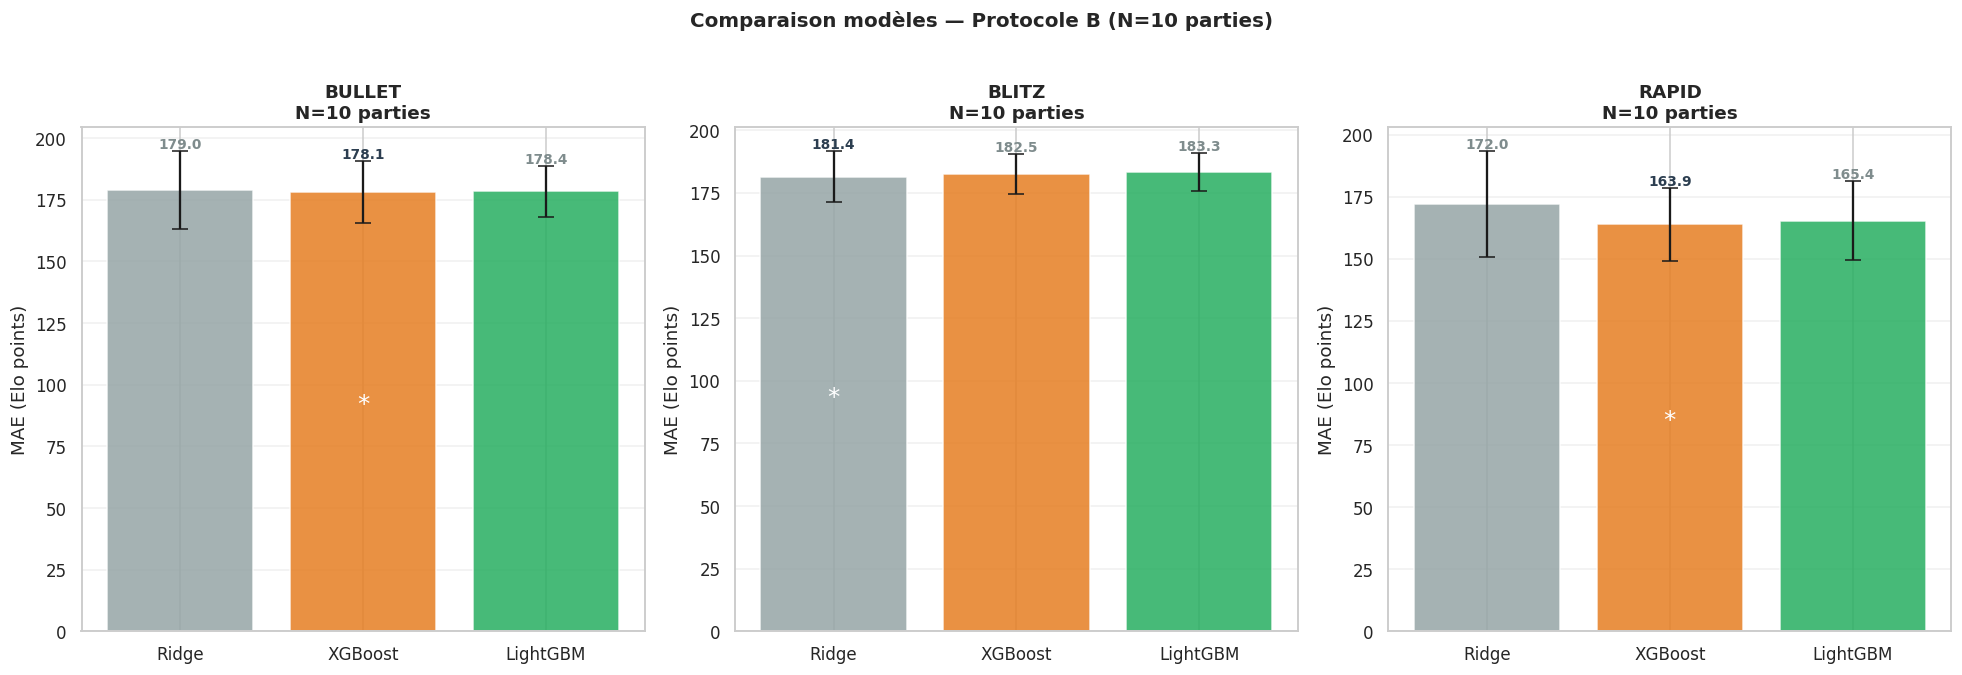

In [18]:
color_map_models = {
    'Ridge': '#95a5a6', 'XGBoost': '#e67e22',
    'LightGBM': '#27ae60', 'CatBoost': '#e74c3c'
}

fig, axes = plt.subplots(1, len(CADENCES_KEEP), figsize=(6 * len(CADENCES_KEEP), 6))
if len(CADENCES_KEEP) == 1:
    axes = [axes]

for ax, speed in zip(axes, CADENCES_KEEP):
    if speed not in all_results:
        ax.set_visible(False)
        continue
    speed_res   = all_results[speed]
    model_names = list(speed_res.keys())
    mae_means   = [speed_res[mn]['MAE_mean'] for mn in model_names]
    mae_stds    = [speed_res[mn]['MAE_std']  for mn in model_names]
    colors      = [color_map_models.get(mn, '#bdc3c7') for mn in model_names]
    bars = ax.bar(model_names, mae_means, color=colors, edgecolor='white',
                  alpha=0.85, yerr=mae_stds, capsize=5)
    ax.set_title(f'{speed.upper()}\nN={N_GAMES_PROTO} parties', fontsize=12, fontweight='bold')
    ax.set_ylabel('MAE (Elo points)')
    best = best_models.get(speed)
    for bar, name, val, std in zip(bars, model_names, mae_means, mae_stds):
        ax.text(bar.get_x() + bar.get_width()/2, val + std + 1,
                f'{val:.1f}', ha='center', fontsize=9, fontweight='bold',
                color='#2c3e50' if name == best else '#7f8c8d')
        if name == best:
            ax.text(bar.get_x() + bar.get_width()/2, val/2,
                    '*', ha='center', fontsize=16, color='white')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Comparaison modèles — Protocole B (N={N_GAMES_PROTO} parties)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Section 11 — Feature Importance par Permutation

On utilise la **permutation importance** (sklearn) plutôt que l'importance native
des arbres, car elle mesure l'impact réel sur la MAE en test, indépendamment
de la structure du modèle.

- **Valeur positive** → la feature améliore la prédiction
- **Valeur négative ou nulle** → candidate au pruning


In [20]:
def tag_bloc(name):
    """Classe chaque feature dans son bloc fonctionnel."""
    if any(k in name for k in ['time', 'clock', 'low_time', 'fast_move', 'pressure']):
        return 'Temps'
    if any(k in name for k in ['loss', 'rate_good', 'rate_error', 'rate_blunder',
                                'rate_mistake', 'rate_inaccuracy', 'n_blunders',
                                'n_mistakes', 'rate_loss']):
        return 'Qualite'
    if any(k in name for k in ['when_', 'opening', 'middlegame', 'endgame',
                                'winning', 'equal', 'losing']):
        return 'Contexte'
    if any(k in name for k in ['variance', 'stability', 'drift', 'gap',
                                'drop', 'cv', 'prop_games']):
        return 'Stabilite'
    if any(k in name for k in ['capture', 'check', 'castle', 'promotion',
                                'eco', 'speed', 'n_moves', 'ply', 'win_rate']):
        return 'Style'
    return 'Autre'

PALETTE_BLOC = {
    'Qualite':   '#3498db',
    'Temps':     '#e74c3c',
    'Contexte':  '#2ecc71',
    'Stabilite': '#f39c12',
    'Style':     '#9b59b6',
    'Autre':     '#95a5a6',
}

print("\n" + "=" * 60)
print("  SECTION 11 — Feature importance par cadence")
print("=" * 60)

feature_importance_results = {}
pruning_candidates = {}

for speed in CADENCES_KEEP:
    if speed not in best_models or speed not in all_datasets:
        continue

    best_model_name = best_models[speed]
    X_all, y_all, feat_cols = all_datasets[speed]
    print(f"\n--- {speed.upper()} — Meilleur modèle : {best_model_name} ---")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
    )
    imputer  = SimpleImputer(strategy='median')
    X_tr_imp = imputer.fit_transform(X_tr)
    X_te_imp = imputer.transform(X_te)

    if best_model_name == 'Ridge':
        scaler    = StandardScaler()
        X_tr_sc   = scaler.fit_transform(X_tr_imp)
        X_te_sc   = scaler.transform(X_te_imp)
        base_model = Ridge(alpha=10.0)
        base_model.fit(X_tr_sc, y_tr)
        X_te_for_perm = X_te_sc
    elif best_model_name == 'XGBoost' and XGBOOST_AVAILABLE:
        base_model = xgb.XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.5, reg_lambda=2.0,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
        base_model.fit(X_tr_imp, y_tr)
        X_te_for_perm = X_te_imp
    elif best_model_name == 'LightGBM' and LIGHTGBM_AVAILABLE:
        base_model = lgb.LGBMRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            num_leaves=20, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.5, reg_lambda=2.0, min_child_samples=10,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        base_model.fit(X_tr_imp, y_tr)
        X_te_for_perm = X_te_imp
    elif best_model_name == 'CatBoost' and CATBOOST_AVAILABLE:
        base_model = CatBoostRegressor(
            iterations=300, depth=4, learning_rate=0.05,
            l2_leaf_reg=5.0, random_seed=RANDOM_STATE, verbose=0)
        base_model.fit(X_tr_imp, y_tr)
        X_te_for_perm = X_te_imp
    else:
        continue

    perm_result = permutation_importance(
        base_model, X_te_for_perm, y_te,
        n_repeats=10, random_state=RANDOM_STATE,
        scoring='neg_mean_absolute_error'
    )

    imp_df = pd.DataFrame({
        'feature':    feat_cols,
        'importance': perm_result.importances_mean,
        'std':        perm_result.importances_std,
    })
    imp_df['bloc'] = imp_df['feature'].apply(tag_bloc)
    imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
    feature_importance_results[speed] = imp_df

    top15    = imp_df.head(15)
    bottom15 = imp_df.tail(15).sort_values('importance')
    threshold_prune = imp_df['importance'].quantile(0.20)
    candidates = imp_df[imp_df['importance'] <= max(0, threshold_prune)]['feature'].tolist()
    pruning_candidates[speed] = candidates

    print(f"\n  Top 15 features :")
    for _, row in top15.iterrows():
        print(f"    [{row['bloc']:10s}] {row['feature']:50s} {row['importance']:+.4f} ±{row['std']:.4f}")

    print(f"\n  Bottom 15 features (candidats pruning) :")
    for _, row in bottom15.iterrows():
        marker = '!' if row['importance'] <= 0 else ' '
        print(f"  {marker} [{row['bloc']:10s}] {row['feature']:50s} {row['importance']:+.4f} ±{row['std']:.4f}")

    bloc_imp = imp_df.groupby('bloc')['importance'].sum().sort_values(ascending=False)
    print(f"\n  Importance par bloc :")
    for bloc, val in bloc_imp.items():
        bar = '#' * max(0, int(val * 20))
        print(f"    {bloc:12s} : {val:+.3f}  {bar}")

    print(f"\n  Candidats au pruning ({len(candidates)} features) :")
    for feat in candidates[:10]:
        print(f"    - {feat}")
    if len(candidates) > 10:
        print(f"    ... et {len(candidates)-10} autres")



  SECTION 11 — Feature importance par cadence

--- BULLET — Meilleur modèle : XGBoost ---

  Top 15 features :
    [Temps     ] good_fast_move_rate_mean                           +14.1193 ±2.4579
    [Temps     ] time_median_s_std                                  +13.6134 ±5.9702
    [Temps     ] time_endgame_mean_s_mean                           +6.3291 ±1.8892
    [Temps     ] time_median_s_mean                                 +5.5771 ±3.6605
    [Qualite   ] loss_opening_std_mean                              +4.5786 ±1.0666
    [Temps     ] time_mean_on_blunder_mean                          +3.7812 ±1.2952
    [Style     ] win_rate                                           +2.7385 ±0.8203
    [Qualite   ] loss_opening_std_std                               +2.4001 ±0.7686
    [Qualite   ] loss_opening_mean_mean                             +2.2426 ±0.7980
    [Temps     ] time_middlegame_mean_s_mean                        +1.8165 ±0.4930
    [Qualite   ] rate_blunder_opening_mean    

---
## Section 12 — Graphiques Feature Importance par Cadence

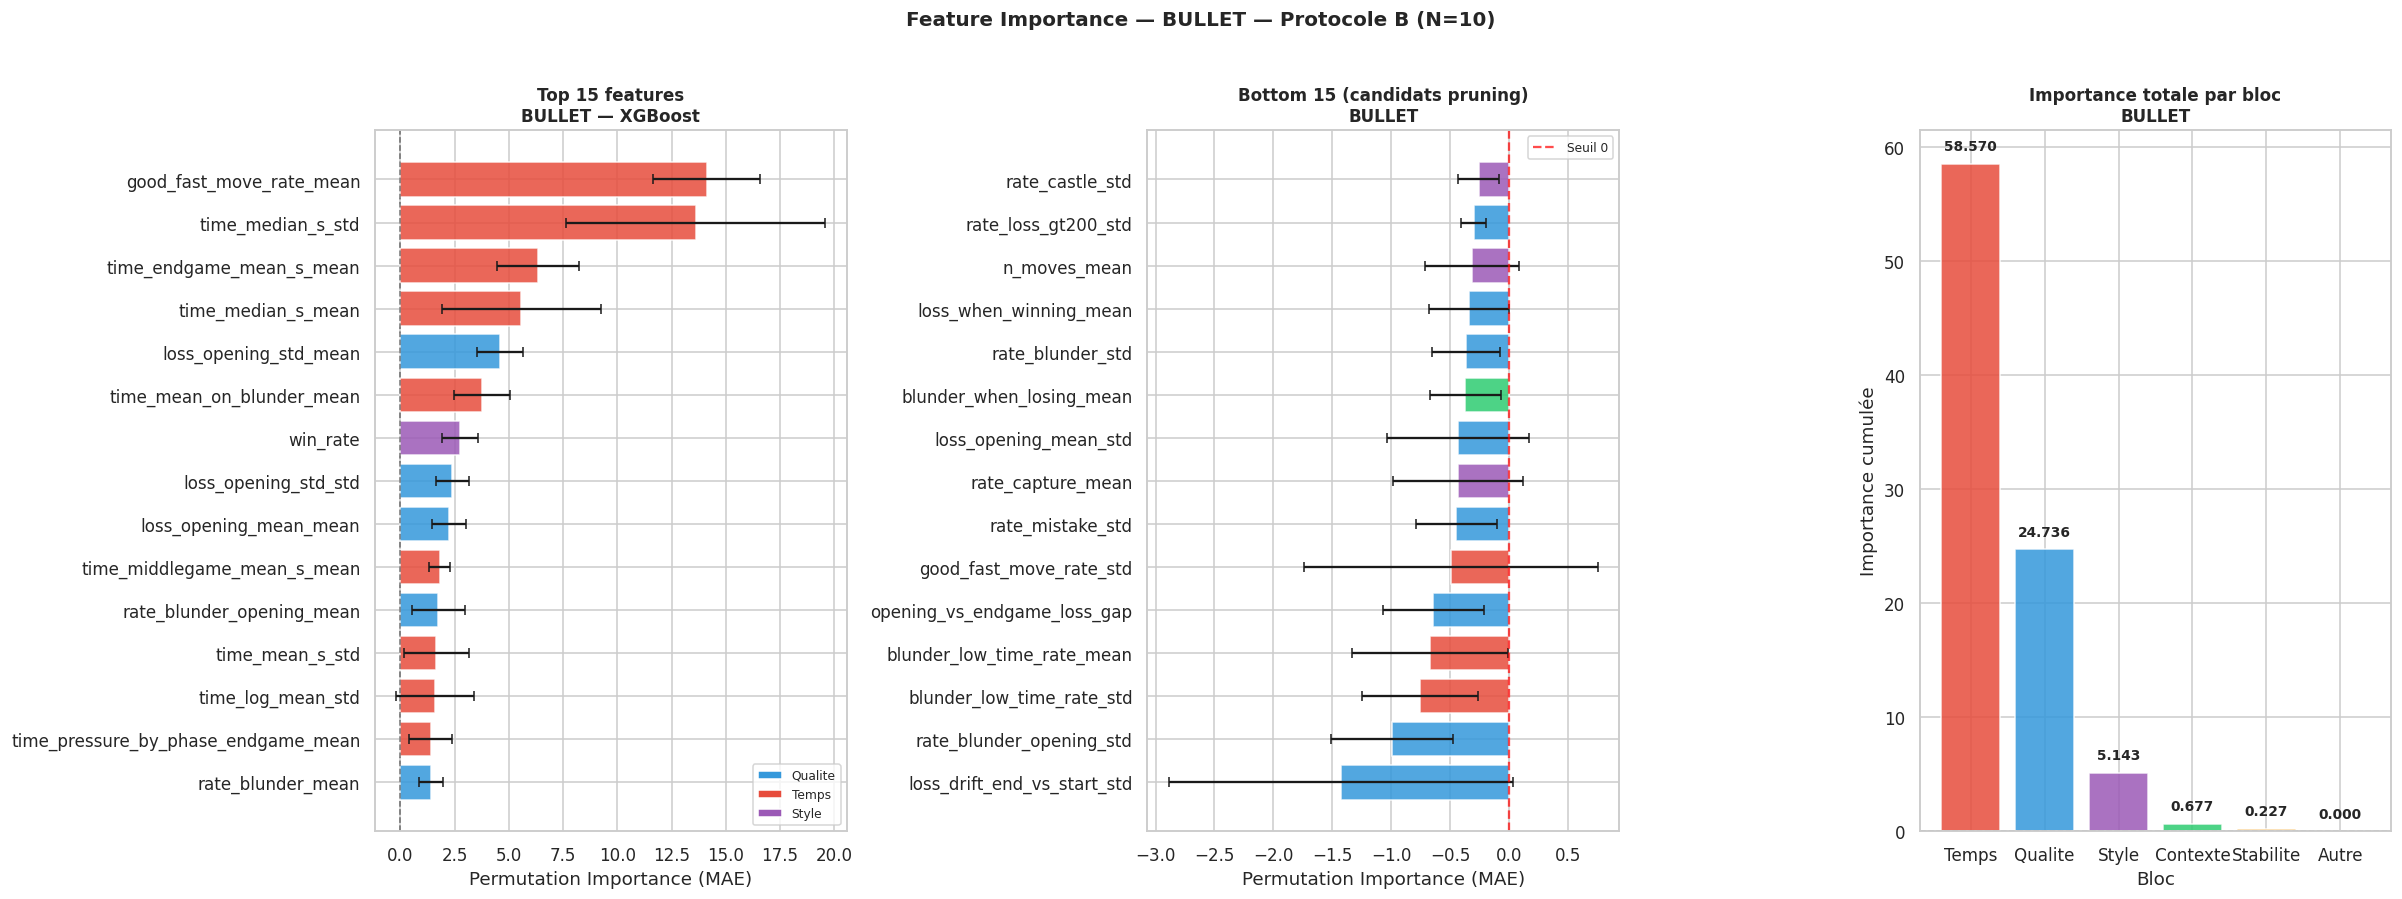

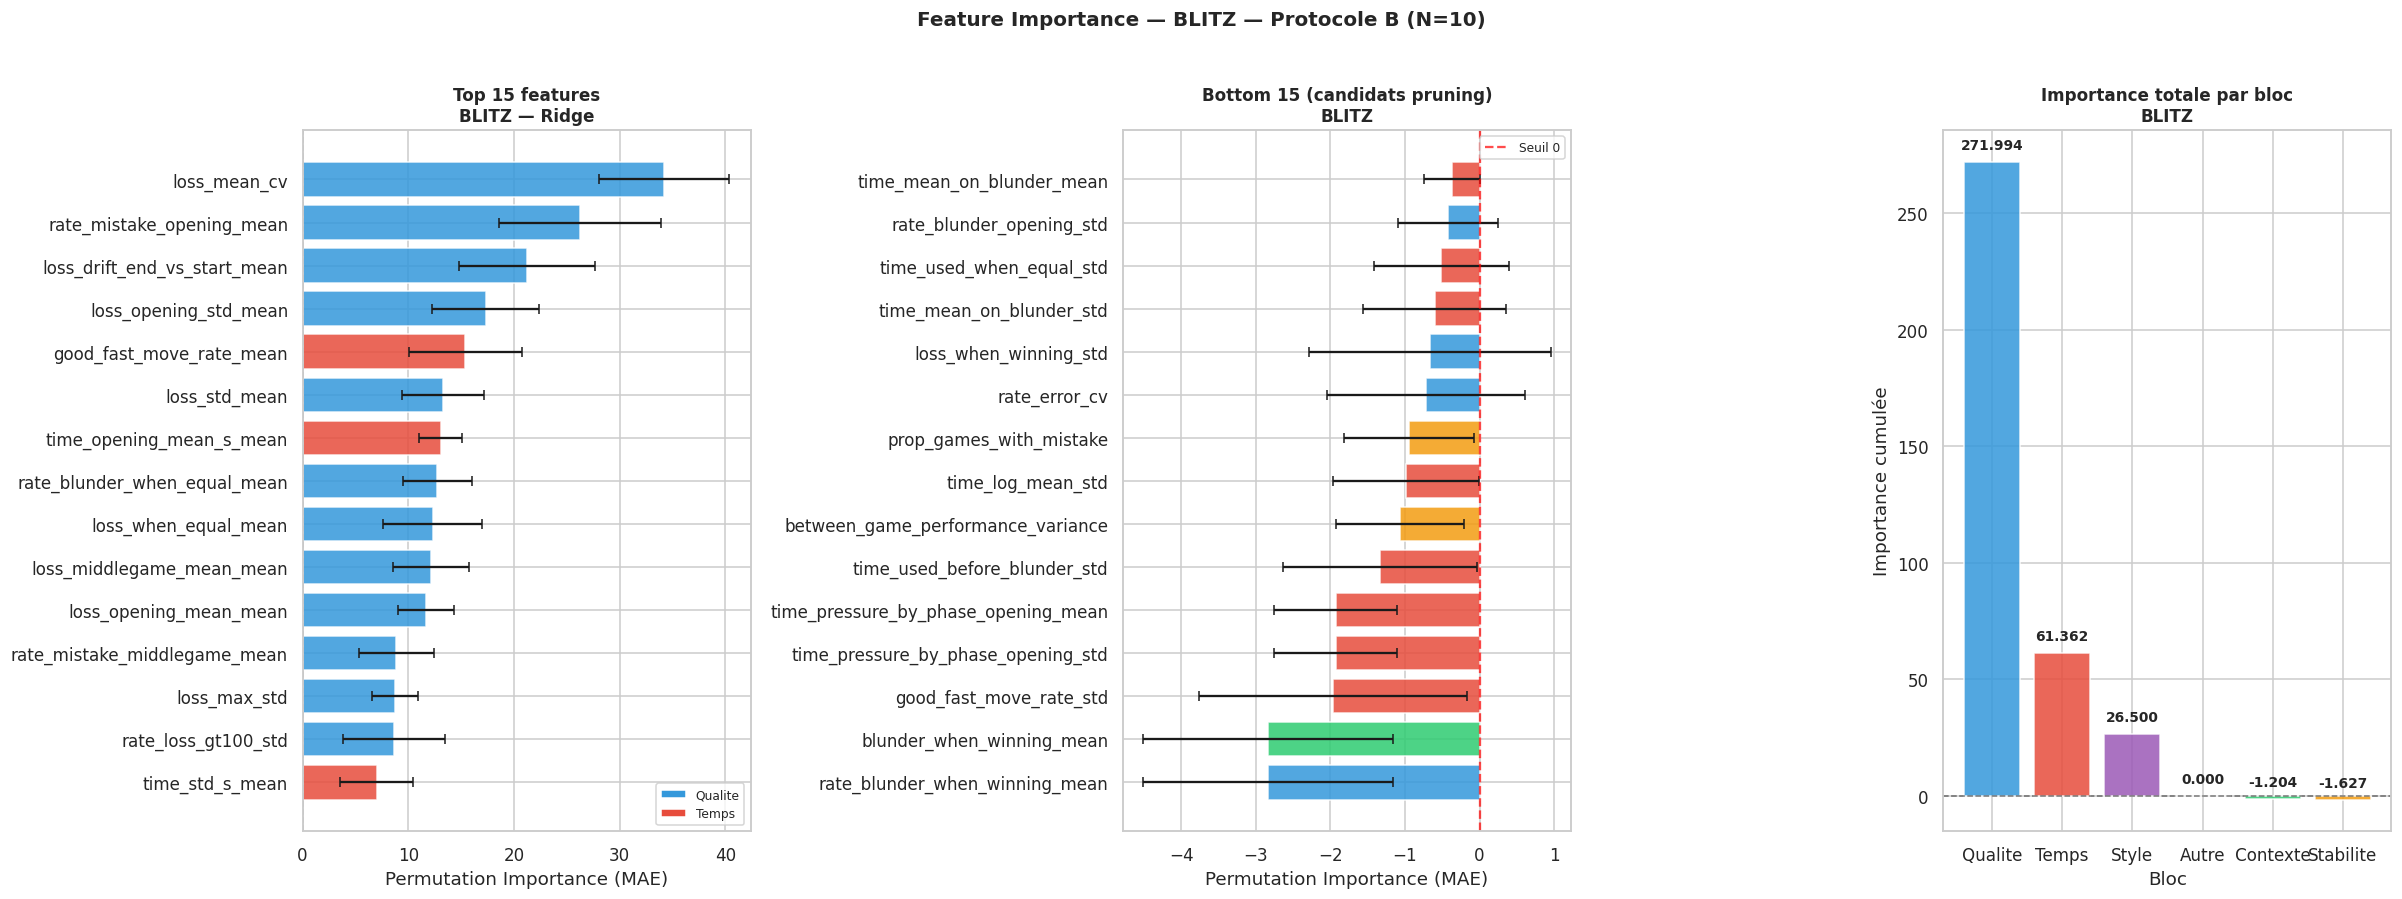

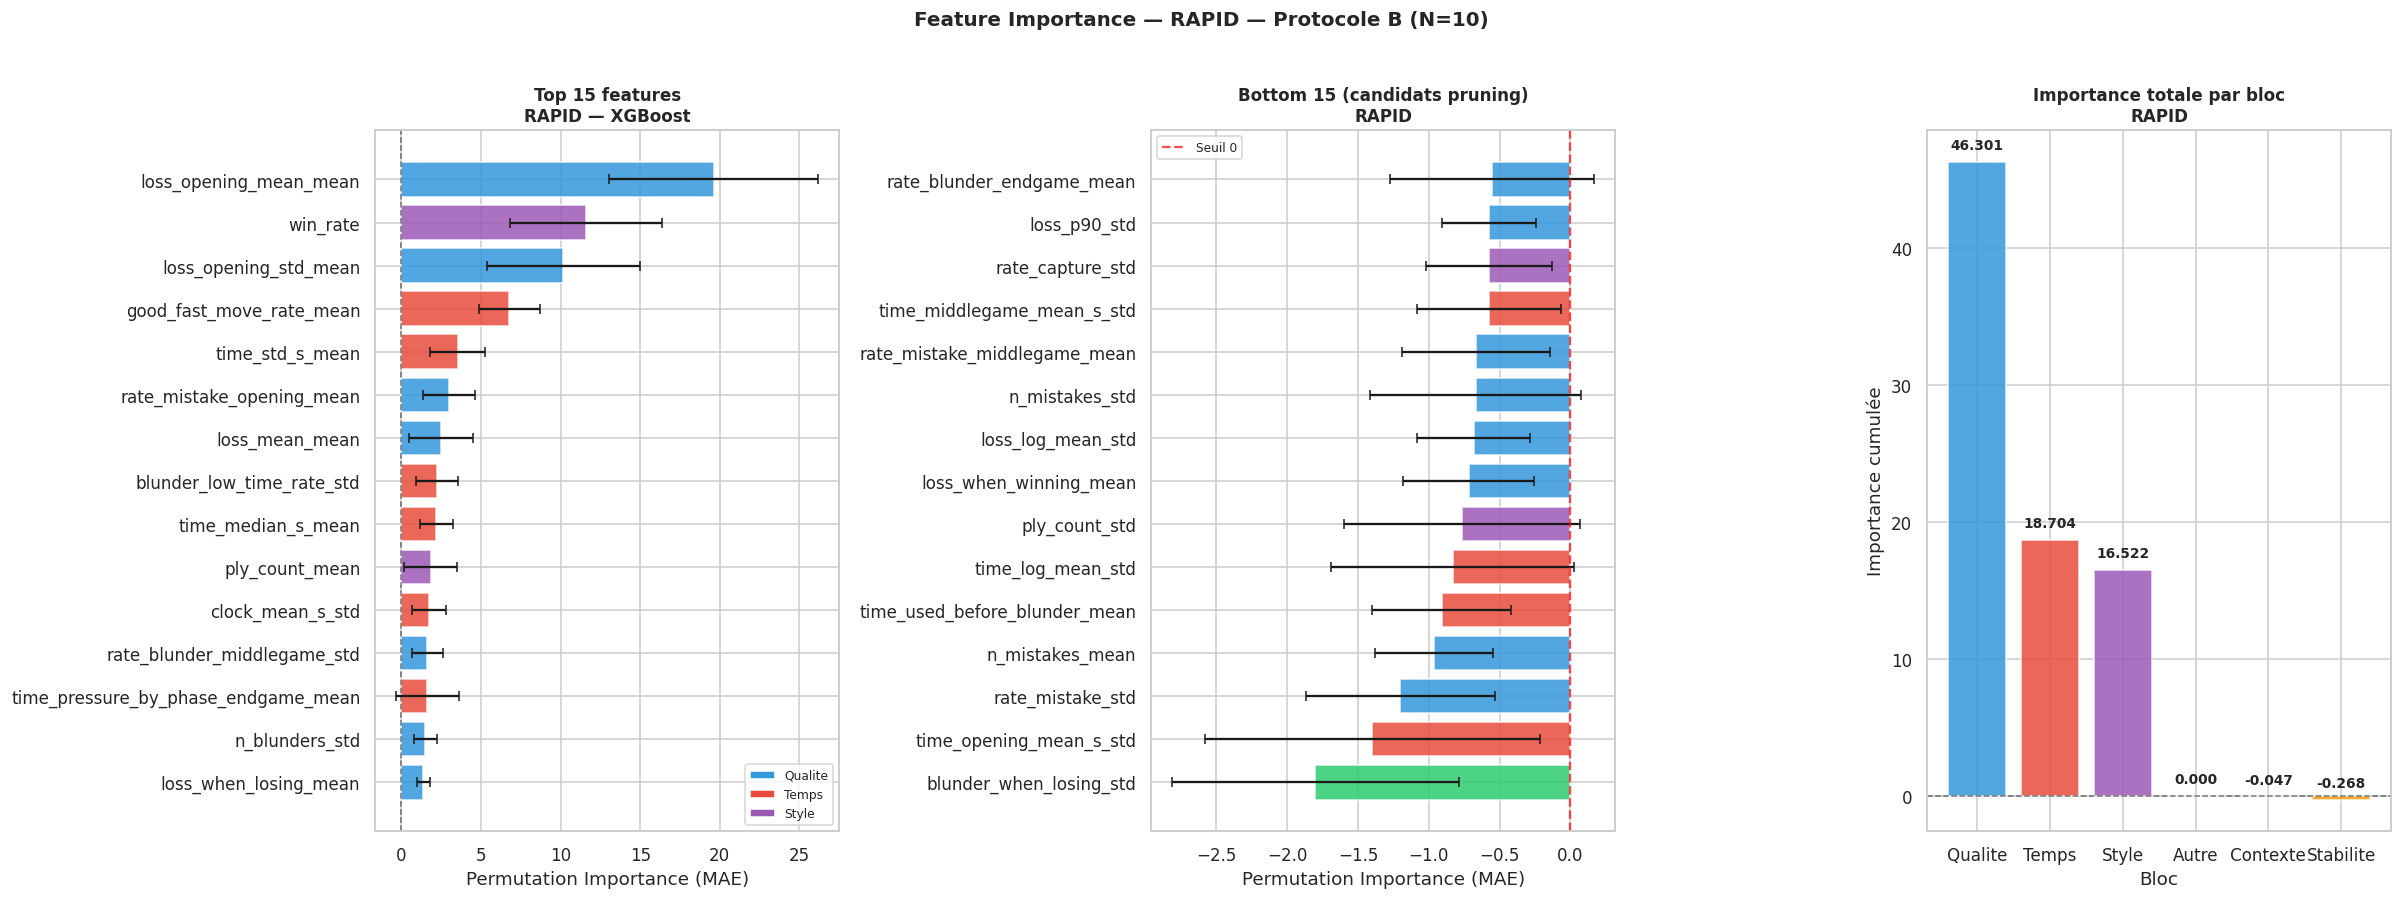

In [21]:
for speed in CADENCES_KEEP:
    if speed not in feature_importance_results:
        continue

    imp_df          = feature_importance_results[speed]
    best_model_name = best_models.get(speed, '?')

    fig, axes = plt.subplots(1, 3, figsize=(22, 8))

    # Top 15
    top15       = imp_df.head(15).sort_values('importance')
    colors_top  = top15['bloc'].map(PALETTE_BLOC)
    axes[0].barh(top15['feature'], top15['importance'], color=colors_top,
                 edgecolor='white', alpha=0.85, xerr=top15['std'], capsize=3)
    axes[0].axvline(0, color='black', lw=1, linestyle='--', alpha=0.5)
    axes[0].set_title(f'Top 15 features\n{speed.upper()} — {best_model_name}',
                      fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Permutation Importance (MAE)')
    legend_els = [mpatches.Patch(facecolor=v, label=k)
                  for k, v in PALETTE_BLOC.items() if k in top15['bloc'].values]
    axes[0].legend(handles=legend_els, fontsize=8, loc='lower right')

    # Bottom 15
    bottom15    = imp_df.tail(15).sort_values('importance')
    colors_bot  = bottom15['bloc'].map(PALETTE_BLOC)
    axes[1].barh(bottom15['feature'], bottom15['importance'], color=colors_bot,
                 edgecolor='white', alpha=0.85, xerr=bottom15['std'], capsize=3)
    axes[1].axvline(0, color='red', lw=1.5, linestyle='--', alpha=0.7, label='Seuil 0')
    axes[1].set_title(f'Bottom 15 (candidats pruning)\n{speed.upper()}',
                      fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Permutation Importance (MAE)')
    axes[1].legend(fontsize=8)

    # Importance par bloc
    bloc_imp    = imp_df.groupby('bloc')['importance'].sum().sort_values(ascending=False)
    bloc_colors = [PALETTE_BLOC.get(b, '#95a5a6') for b in bloc_imp.index]
    bars = axes[2].bar(bloc_imp.index, bloc_imp.values, color=bloc_colors,
                       edgecolor='white', alpha=0.85)
    axes[2].axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
    axes[2].set_title(f'Importance totale par bloc\n{speed.upper()}',
                      fontsize=11, fontweight='bold')
    axes[2].set_xlabel('Bloc'); axes[2].set_ylabel('Importance cumulée')
    for bar, (bloc, val) in zip(bars, bloc_imp.items()):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     val + abs(bloc_imp.max()) * 0.02,
                     f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

    plt.suptitle(f'Feature Importance — {speed.upper()} — Protocole B (N={N_GAMES_PROTO})',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


---
## Section 13 — Comparaison des Blocs entre Cadences


  SECTION 13 — Comparaison blocs entre cadences

Importance par bloc et par cadence :
           bullet   blitz  rapid
bloc                            
Autre       0.000   0.000  0.000
Contexte    0.677  -1.204 -0.047
Qualite    24.736 271.994 46.301
Stabilite   0.227  -1.627 -0.268
Style       5.143  26.500 16.522
Temps      58.570  61.362 18.704


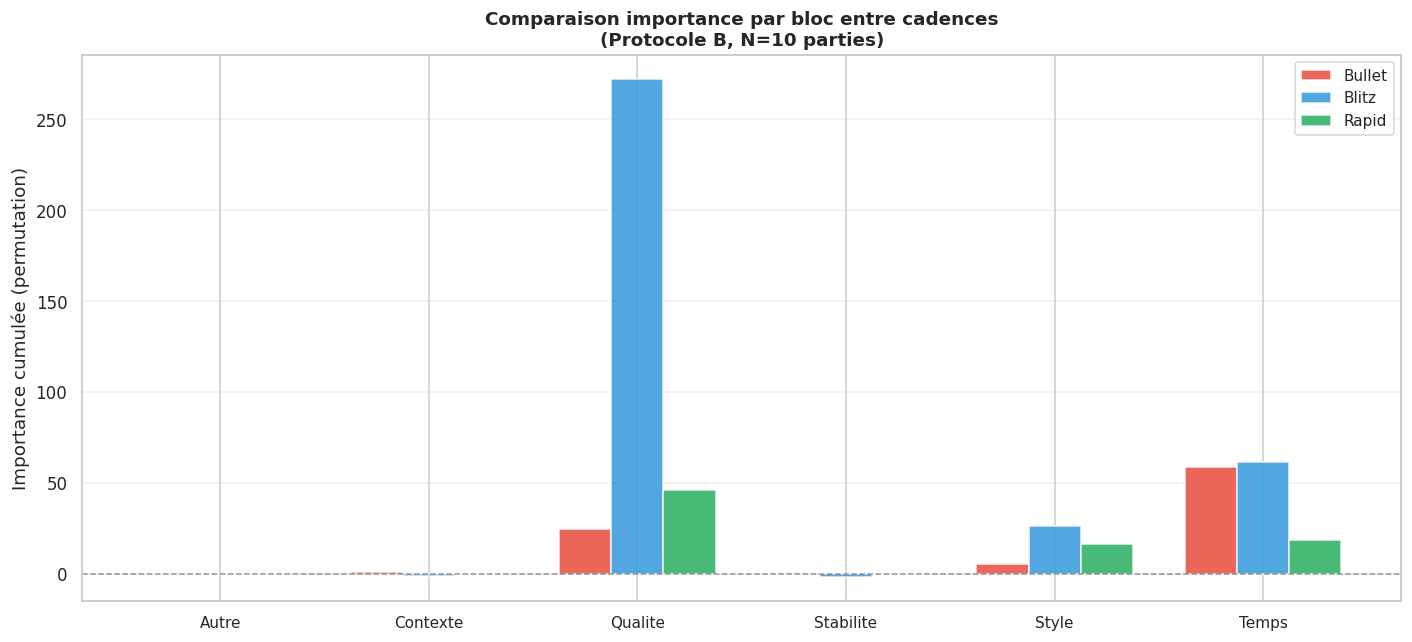

In [22]:
print("\n" + "=" * 60)
print("  SECTION 13 — Comparaison blocs entre cadences")
print("=" * 60)

bloc_comparison = {}
for speed in CADENCES_KEEP:
    if speed not in feature_importance_results:
        continue
    imp_df = feature_importance_results[speed]
    bloc_comparison[speed] = imp_df.groupby('bloc')['importance'].sum()

if bloc_comparison:
    df_blocs = pd.DataFrame(bloc_comparison).fillna(0)
    print("\nImportance par bloc et par cadence :")
    print(df_blocs.round(3).to_string())

    blocs         = df_blocs.index.tolist()
    x             = np.arange(len(blocs))
    width         = 0.25
    colors_speed  = {'bullet': '#e74c3c', 'blitz': '#3498db', 'rapid': '#27ae60'}

    fig, ax = plt.subplots(figsize=(13, 6))
    for i, speed in enumerate(CADENCES_KEEP):
        if speed not in df_blocs.columns:
            continue
        ax.bar(x + i * width, df_blocs[speed].values, width,
               label=speed.capitalize(),
               color=colors_speed.get(speed, '#95a5a6'), edgecolor='white', alpha=0.85)

    ax.set_xticks(x + width)
    ax.set_xticklabels(blocs, fontsize=10)
    ax.set_ylabel('Importance cumulée (permutation)')
    ax.set_title(f'Comparaison importance par bloc entre cadences\n'
                 f'(Protocole B, N={N_GAMES_PROTO} parties)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.4)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


---
## Section 14 — Synthèse Finale & Recommandations

In [23]:
print("\n" + "=" * 70)
print("  SECTION 14 — SYNTHÈSE FINALE")
print("=" * 70)

print("\n--- Meilleur modèle par cadence (Protocole B, N=10) ---")
for speed in CADENCES_KEEP:
    if speed not in best_models:
        continue
    model_name = best_models[speed]
    res = all_results[speed][model_name]
    print(f"  {speed:8s} -> {model_name:12s}  "
          f"MAE={res['MAE_mean']:.1f} ±{res['MAE_std']:.1f}  R²={res['R2_mean']:.3f}")

print("\n--- Blocs les plus importants par cadence ---")
for speed in CADENCES_KEEP:
    if speed not in feature_importance_results:
        continue
    imp_df   = feature_importance_results[speed]
    bloc_imp = imp_df.groupby('bloc')['importance'].sum().sort_values(ascending=False)
    top_blocs = bloc_imp[bloc_imp > 0].head(3)
    print(f"  {speed:8s} -> {list(top_blocs.index)}")

print("\n--- Features candidates au pruning par cadence ---")
for speed in CADENCES_KEEP:
    if speed not in pruning_candidates:
        continue
    cands = pruning_candidates[speed]
    print(f"  {speed:8s} -> {len(cands)} features à considérer pour suppression")
    for feat in cands[:8]:
        print(f"    - {feat}")
    if len(cands) > 8:
        print(f"    ... et {len(cands)-8} autres")

print("\n--- Recommandations pour la prochaine itération ---")
print("  1. Garder uniquement les features avec importance > 0 (permutation)")
print("  2. Supprimer les features du bottom 20% si importance <= 0")
print("  3. Vérifier si les blocs 'Stabilite' et 'Style' sont utiles à N=10")
print("  4. Attendre les nouvelles données pour valider sur plus de parties")
print("  5. Relancer ce notebook avec N=20 et N=30 quand les données seront disponibles")
print("\n✓ Notebook V6 terminé.")



  SECTION 14 — SYNTHÈSE FINALE

--- Meilleur modèle par cadence (Protocole B, N=10) ---
  bullet   -> XGBoost       MAE=178.1 ±12.6  R²=0.435
  blitz    -> Ridge         MAE=181.4 ±10.1  R²=0.458
  rapid    -> XGBoost       MAE=163.9 ±14.7  R²=0.432

--- Blocs les plus importants par cadence ---
  bullet   -> ['Temps', 'Qualite', 'Style']
  blitz    -> ['Qualite', 'Temps', 'Style']
  rapid    -> ['Qualite', 'Temps', 'Style']

--- Features candidates au pruning par cadence ---
  bullet   -> 38 features à considérer pour suppression
    - time_pressure_by_phase_opening_std
    - n_games
    - between_game_error_variance
    - prop_games_with_mistake
    - time_used_before_blunder_std
    - rate_check_std
    - time_mean_on_error_mean
    - eco_diversity
    ... et 30 autres
  blitz    -> 35 features à considérer pour suppression
    - n_games
    - time_pressure_by_phase_middlegame_mean
    - rate_mistake_middlegame_std
    - time_mean_on_error_mean
    - rate_inaccuracy_mean
    - rate